In [114]:
import torch
from torch import nn
import ptwt
import numpy as np
from torch_geometric.nn.conv import GATConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from dataset import EEGDataset
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
from torchaudio.transforms import PSD
from Model.MENDR.SpatialTemporalLayers import TimesBlock

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
train_frac = 0.02
val_frac = 0.001

dataset = EEGDataset(root="/home/hice1/mchen439/data/TUH-Processed", frac=train_frac + val_frac)
num_train = int(len(dataset) * (train_frac / (train_frac + val_frac)))
num_val = len(dataset) - num_train
train_dataset, val_dataset = torchdata.random_split(dataset, [num_train, num_val])
print("Train and Validation Dataset Length: ", len(train_dataset), len(val_dataset))

Loading 314 subjects


100%|██████████| 314/314 [00:17<00:00, 17.56it/s]


Train and Validation Dataset Length:  14524 727


In [4]:
train_loader = DataLoader(train_dataset, batch_size=1024, num_workers=0, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, num_workers=0, shuffle=False)
print(len(train_loader), len(val_loader))

15 1


In [5]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

In [23]:
class WaveletEncoderDecoder(nn.Module):
	def __init__(self, bands, decoded_features, encoded_features, enc_width, enc_downsample):
		super(WaveletEncoderDecoder, self).__init__()

		self.encoders = nn.ParameterDict()
		self.decoded_features = decoded_features
		self.encoded_features = encoded_features

		enc_width = [e if e % 2 else e+1 for e in enc_width]

		band_input = {
			'delta': 241,
			'theta': 241,
			'alpha': 481,
			'beta': 961,
			'gamma': 1921
		}

		band_output = {
			'delta': 246,
			'theta': 246,
			'alpha': 486,
			'beta': 966,
			'gamma': 1926
		}

		for band in bands:
			self.encoders[band] = nn.Sequential()
			decoded_features = self.decoded_features
			for i, (width, downsample) in enumerate(zip(enc_width, enc_downsample)):
				self.encoders[band].add_module("Encoder_{}".format(i), nn.Sequential(
					nn.Conv1d(decoded_features, encoded_features, width, stride=downsample, padding=width // 2),
					nn.Dropout1d(0.1),
					nn.GroupNorm(encoded_features // 2, encoded_features),
					nn.GELU(),
				))
				decoded_features = encoded_features

		self.decoders = nn.ParameterDict()
		decoded_features = self.decoded_features
		for band in bands:
			self.decoders[band] = nn.Sequential()
			encoded_features = self.encoded_features	
			for i, (width, upsample) in enumerate(zip(enc_width[::-1], enc_downsample[::-1])):
				self.decoders[band].add_module("Decoder_{}".format(i), nn.Sequential(
					nn.ConvTranspose1d(encoded_features, decoded_features, width, stride=upsample, padding=width // 2),
					nn.Dropout(0.1),
					nn.GroupNorm(1, decoded_features),
					nn.GELU(),
				))
				encoded_features = decoded_features
			
			self.decoders[band].add_module("Decoder_Final", nn.Linear(band_input[band], band_output[band]))


	def forward(self, data):
		assert isinstance(data, dict)
		encodings = dict()

		for band in BANDS:
			encodings[band] = self.encoders[band](data[band])

		decodings = dict()

		for band in BANDS:
			decodings[band] = self.decoders[band](encodings[band])

		return encodings, decodings


In [7]:
class GNNWaveletEncoderDecoder(nn.Module):
	def __init__(self, bands, num_channels, enc_width, enc_downsample, heads):
		super(GNNWaveletEncoderDecoder, self).__init__()

		self.conv_encoders = nn.ParameterDict()
		self.decoders = nn.ParameterDict()

		self.enc_width = [e if e % 2 else e+1 for e in enc_width]
		self.enc_downsample = enc_downsample

		self.num_channels = num_channels

		self.gnn_encoders = nn.ParameterDict()
		self.encoded_features = []
		self.heads = heads

		self.band_input = {
			'delta': 11,
			'theta': 11,
			'alpha': 21,
			'beta': 41,
			'gamma': 81
		}

		self.band_linear = {
			'delta': 220,
			'theta': 220,
			'alpha': 460,
			'beta': 940,
			'gamma': 1900
		}

		self.band_output = {
			'delta': 246,
			'theta': 246,
			'alpha': 486,
			'beta': 966,
			'gamma': 1926
		}

		for band in bands:
			self.conv_encoders[band] = nn.Sequential()
			for i, (width, downsample) in enumerate(zip(self.enc_width, self.enc_downsample)):
				self.conv_encoders[band].add_module("Encoder_{}".format(i), nn.Sequential(
					nn.Conv1d(self.num_channels, self.num_channels, width, stride=downsample, padding=width // 2),
					nn.Dropout1d(0.1),
					nn.GroupNorm(1, self.num_channels), # Equivalent to LayerNorm
					nn.GELU(),
				))

			self.gnn_encoders[band] = Sequential('x, edge_index, edge_attr', [
				(GATConv(self.band_input[band], self.band_input[band], heads=self.heads, concat=False, dropout=0.1), 'x, edge_index, edge_attr -> x'),
				(GATConv(self.band_input[band], self.band_input[band], heads=self.heads, concat=False, dropout=0.1), 'x, edge_index, edge_attr -> x'),
			])


		for band in bands:
			self.decoders[band] = nn.Sequential()
			for i, (width, upsample) in enumerate(zip(enc_width[::-1], enc_downsample[::-1])):
				self.decoders[band].add_module("Decoder_{}".format(i), nn.Sequential(
					nn.ConvTranspose1d(num_channels, num_channels, width, stride=upsample, padding=width // 2),
					nn.Dropout(0.1),
					nn.GroupNorm(1, self.num_channels),
					nn.GELU(),
				))
			
			self.decoders[band].add_module("Decoder_Final", nn.Linear(self.band_linear[band], self.band_output[band]))


	def forward(self, x, data):
		assert isinstance(data, dict)
		encodings = dict()

		for band in BANDS:
			encodings[band] = self.conv_encoders[band](data[band])
			encodings[band] = self.gnn_encoders[band](encodings[band].view(-1, encodings[band].shape[-1]), x.edge_index, x.edge_attr)

		decodings = dict()

		for band in BANDS:
			raw_data = encodings[band].view(-1, self.num_channels, encodings[band].shape[-1])
			decodings[band] = self.decoders[band](raw_data)

		return encodings, decodings


In [143]:
from types import SimpleNamespace
class TimesNetEncoderDecoder(nn.Module):
    def __init__(self, num_layers, seq_len, top_k, d_model, d_ff, num_kernels, enc_downsample):
        super(TimesNetEncoderDecoder, self).__init__()

        assert len(enc_downsample) == len(d_model) == len(num_kernels) == len(d_ff) == len(top_k) == num_layers

        self.num_layers = num_layers
        self.d_model = d_model
        self.num_kernels = num_kernels
        self.d_ff = d_ff
        self.top_k = top_k
        self.seq_len = seq_len
        self.pred_len = []

        self.TimesNetEncoders = nn.ParameterList()
        self.TimesNetDecoders = nn.ParameterList()

        for layer_idx in range(self.num_layers):
            if self.pred_len:
                self.pred_len.append(self.pred_len[-1] // enc_downsample[layer_idx])
            else:
                self.pred_len.append(self.seq_len // enc_downsample[layer_idx])

        self.encoder_linear(self.seq_len, seq_len)

        for layer_idx in range(num_layers):
            if layer_idx == 0:
                seq_len = self.seq_len
            else:
                seq_len = self.pred_len[layer_idx - 1]            

            config = SimpleNamespace(
                seq_len = seq_len,
                pred_len = self.pred_len[layer_idx],
                top_k = self.top_k[layer_idx],
                d_model = self.d_model[layer_idx],
                d_ff = self.d_ff[layer_idx],
                num_kernels = self.num_kernels[layer_idx]
            )
            self.TimesNetEncoders.append(TimesBlock(config))

        for layer_idx in range(num_layers - 1, -1, -1):
            if layer_idx == 0:
                seq_len = self.seq_len
            else:
                seq_len = self.pred_len[layer_idx]            
            config = SimpleNamespace(
                seq_len = seq_len,
                pred_len = self.pred_len[layer_idx],
                top_k = self.top_k[layer_idx],
                d_model = self.d_model[layer_idx],
                d_ff = self.d_ff[layer_idx],
                num_kernels = self.num_kernels[layer_idx]
            )

            self.TimesNetDecoders.append(TimesBlock(config))


    def forward(self, x):
        for idx, encoder in enumerate(self.TimesNetEncoders):
            x = encoder(x)

        encodings = x.clone()
        for idx, decoder in enumerate(self.TimesNetDecoders):
            x = decoder(x)

        decodings = x.clone()
        return encodings, decodings


In [164]:
enc_width = (3, 2, 2, 2)
enc_downsample = (3, 2, 2, 2)

#gnn_wavelet = GNNWaveletEncoderDecoder(bands=BANDS, num_channels=19, enc_downsample=enc_downsample, heads=2, enc_width=enc_width).to(device)
conv_wavelet = WaveletEncoderDecoder(bands=BANDS, decoded_features=19, encoded_features=256, enc_width=enc_width, enc_downsample=enc_downsample).to(device)
'''

timesnet_wavelet = TimesNetEncoderDecoder(
    num_layers = 2,
    seq_len = 246,
    top_k = (3, 3),
    d_model = (19, 19),
    d_ff = (9, 9),
    num_kernels = (3, 3),
    enc_downsample = (2, 2)
)
'''
optimizer = torch.optim.Adam(conv_wavelet.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
print("Total parameters:", sum(p.numel() for p in conv_wavelet.parameters() if p.requires_grad))

Total parameters: 8112165


In [165]:
def fft_loss(output, target):
    output_fft = torch.fft.fft(output, dim=-1)
    output_amplitude = torch.abs(output_fft)
    output_angle = torch.angle(output_fft)

    target_fft = torch.fft.fft(target, dim=-1)
    target_amplitude = torch.abs(target_fft)
    target_angle = torch.abs(target_fft)

    return loss_fn(output_amplitude, target_amplitude) + loss_fn(output_angle, target_angle)

In [152]:
print(conv_wavelet)
#print(timesnet_wavelet)
#print(gnn_wavelet)

WaveletEncoderDecoder(
  (encoders): ParameterDict(
      (delta): Object of type: Sequential
      (theta): Object of type: Sequential
      (alpha): Object of type: Sequential
      (beta): Object of type: Sequential
      (gamma): Object of type: Sequential
    (delta): Sequential(
      (Encoder_0): Sequential(
        (0): Conv1d(19, 256, kernel_size=(3,), stride=(3,), padding=(1,))
        (1): Dropout1d(p=0.1, inplace=False)
        (2): GroupNorm(128, 256, eps=1e-05, affine=True)
        (3): GELU(approximate='none')
      )
      (Encoder_1): Sequential(
        (0): Conv1d(256, 256, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): Dropout1d(p=0.1, inplace=False)
        (2): GroupNorm(128, 256, eps=1e-05, affine=True)
        (3): GELU(approximate='none')
      )
      (Encoder_2): Sequential(
        (0): Conv1d(256, 256, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): Dropout1d(p=0.1, inplace=False)
        (2): GroupNorm(128, 256, eps=1e-05, affine=True)

In [166]:
def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1, 2), keepdim=True)
	std = torch.std(x, dim=(0, 1, 2), keepdim=True)
	x = (x - mean) / std
	return x

In [167]:
def train_one_epoch(model, optimizer, loss_fn, train_loader):
	loss_sum = 0
	model.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	for iteration in pbar:
		data = next(data_iterator).x
		data = torch.tensor(np.array(data)).float().to(device)
		data = _std_norm(data)
		dbt_dwpt = ptwt.WaveletPacket(data,
									wavelet='db4',
									mode='reflect',
									maxlevel=6,
									axis=-1)
		relevant_bands = [dbt_dwpt['aaaaaa'], dbt_dwpt['aaaaad'], dbt_dwpt['aaaad'],
		 dbt_dwpt['aaad'], dbt_dwpt['aad']]

		inputs = dict(zip(BANDS, relevant_bands))

		optimizer.zero_grad()

		encodings, decodings = model(inputs)

		delta_loss = loss_fn(inputs['delta'], decodings['delta']) + fft_loss(inputs['delta'], decodings['delta'])
		theta_loss = loss_fn(inputs['theta'], decodings['theta']) + fft_loss(inputs['theta'], decodings['theta'])
		alpha_loss = loss_fn(inputs['alpha'], decodings['alpha']) + fft_loss(inputs['alpha'], decodings['alpha'])
		beta_loss =  loss_fn(inputs['beta'], decodings['beta']) + fft_loss(inputs['beta'], decodings['beta'])
		gamma_loss = loss_fn(inputs['gamma'], decodings['gamma']) + fft_loss(inputs['gamma'], decodings['gamma'])

		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss.backward()
		optimizer.step()
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())
	
	return loss_sum

In [168]:
def validate_one_epoch(model, loss_fn, val_loader):
	loss_sum = 0
	model.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)
	for iteration in pbar:
		data = next(data_iterator).x
		data = torch.tensor(np.array(data)).float().to(device)
		data = _std_norm(data)

		dbt_dwpt = ptwt.WaveletPacket(data,
									wavelet='db4',
									mode='reflect',
									maxlevel=6,
									axis=-1)
		relevant_bands = [dbt_dwpt['aaaaaa'], dbt_dwpt['aaaaad'], dbt_dwpt['aaaad'],
		 dbt_dwpt['aaad'], dbt_dwpt['aad']]

		inputs = dict(zip(BANDS, relevant_bands))

		encodings, decodings = model(inputs)

		delta_loss = loss_fn(inputs['delta'], decodings['delta']) + fft_loss(inputs['delta'], decodings['delta'])
		theta_loss = loss_fn(inputs['theta'], decodings['theta']) + fft_loss(inputs['theta'], decodings['theta'])
		alpha_loss = loss_fn(inputs['alpha'], decodings['alpha']) + fft_loss(inputs['alpha'], decodings['alpha'])
		beta_loss =  loss_fn(inputs['beta'], decodings['beta']) + fft_loss(inputs['beta'], decodings['beta'])
		gamma_loss = loss_fn(inputs['gamma'], decodings['gamma']) + fft_loss(inputs['gamma'], decodings['gamma'])


		loss = delta_loss + theta_loss + alpha_loss + beta_loss + gamma_loss
		loss_sum += loss.item()

		pbar.set_postfix(loss=loss.item(),
			delta_loss=delta_loss.item(),
			theta_loss=theta_loss.item(),
			alpha_loss=alpha_loss.item(),
			beta_loss=beta_loss.item(),
			gamma_loss=gamma_loss.item())

	return loss_sum

In [169]:
for epoch_idx in range(5):
	training_loss = train_one_epoch(conv_wavelet, optimizer, loss_fn, train_loader)
	val_loss = validate_one_epoch(conv_wavelet, loss_fn, val_loader)
	print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss, "Total Validation Loss: ", val_loss)
	#print("Epoch: ", epoch_idx, "Total Training Loss: ", training_loss)

Validating: 100%|██████████| 1/1 [00:07<00:00,  7.66s/it, alpha_loss=157, beta_loss=461, delta_loss=8.88e+3, gamma_loss=1.24e+3, loss=1.09e+4, theta_loss=177]


Epoch:  0 Total Training Loss:  317273.734375 Total Validation Loss:  10914.1298828125


Validating: 100%|██████████| 1/1 [00:08<00:00,  8.04s/it, alpha_loss=154, beta_loss=336, delta_loss=8.35e+3, gamma_loss=595, loss=9.62e+3, theta_loss=177]


Epoch:  1 Total Training Loss:  181621.712890625 Total Validation Loss:  9615.556640625


Validating: 100%|██████████| 1/1 [00:07<00:00,  7.90s/it, alpha_loss=153, beta_loss=327, delta_loss=7.39e+3, gamma_loss=444, loss=8.49e+3, theta_loss=177]


Epoch:  2 Total Training Loss:  161829.50048828125 Total Validation Loss:  8489.7314453125


Validating: 100%|██████████| 1/1 [00:10<00:00, 10.82s/it, alpha_loss=153, beta_loss=315, delta_loss=7.4e+3, gamma_loss=395, loss=8.44e+3, theta_loss=177]


Epoch:  3 Total Training Loss:  149190.060546875 Total Validation Loss:  8440.66015625


Validating: 100%|██████████| 1/1 [00:10<00:00, 10.34s/it, alpha_loss=153, beta_loss=310, delta_loss=7.74e+3, gamma_loss=372, loss=8.75e+3, theta_loss=177]

Epoch:  4 Total Training Loss:  145775.4130859375 Total Validation Loss:  8753.3056640625


In [15]:
torch.save(gnn_wavelet.state_dict, "/home/hice1/mchen439/scratch/models/GNNWavelet.pt")

In [170]:
conv_wavelet.eval()

for item in val_loader:
    data = item.x
    data = torch.tensor(np.array(data)).float().to(device)
    data = _std_norm(data)
    dbt_dwpt = ptwt.WaveletPacket(data,
                                wavelet='db4',
                                mode='reflect',
                                maxlevel=6,
                                axis=-1)
    relevant_bands = [dbt_dwpt['aaaaaa'], dbt_dwpt['aaaaad'], dbt_dwpt['aaaad'],
        dbt_dwpt['aaad'], dbt_dwpt['aad']]

    inputs = dict(zip(BANDS, relevant_bands))
    encodings, decodings = conv_wavelet(inputs)

    print(inputs['delta'].shape, encodings['delta'].shape, decodings['delta'].shape)



torch.Size([727, 19, 246]) torch.Size([727, 256, 11]) torch.Size([727, 19, 246])


In [158]:
print(inputs['delta'].shape, encodings['delta'].shape, decodings['delta'].shape)

torch.Size([727, 19, 246]) torch.Size([727, 256, 11]) torch.Size([727, 19, 246])


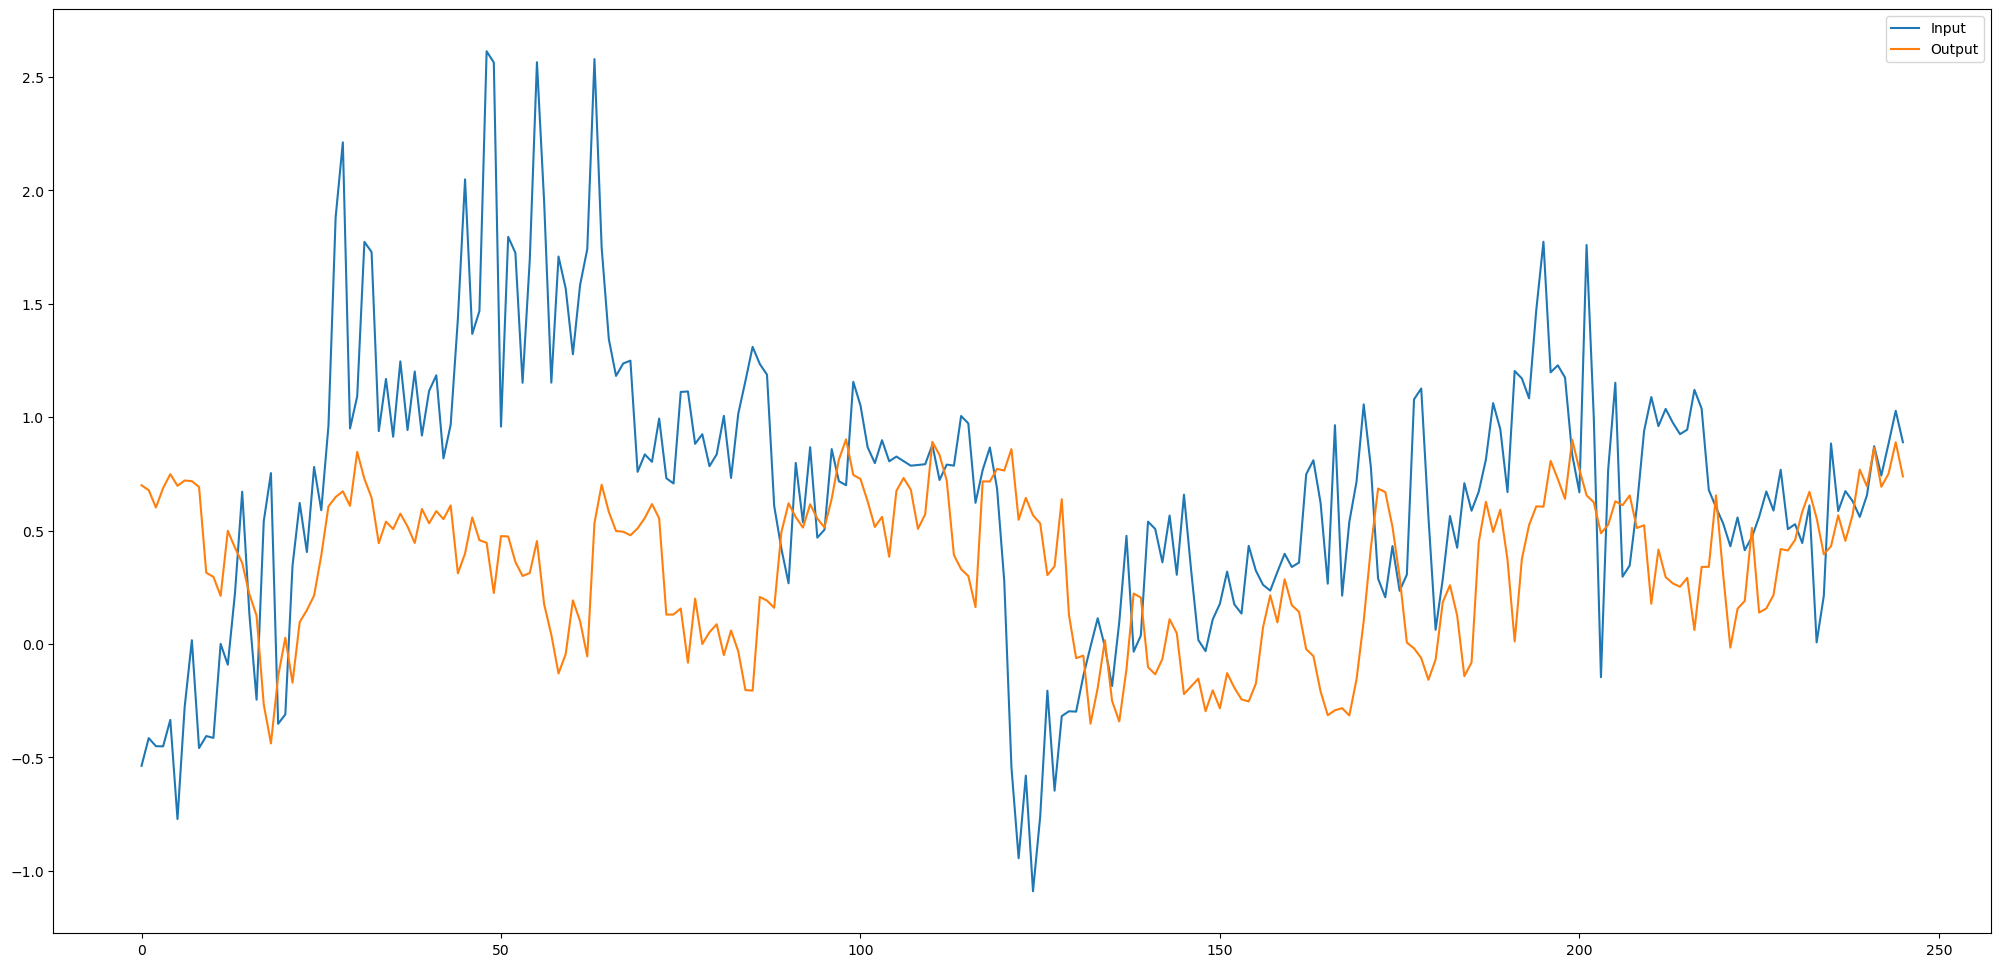

In [172]:
import matplotlib.pyplot as plt
band = 'delta'
channel = 15

plt.figure(figsize=(25, 12))
plt.plot(inputs[band][0, channel, :].cpu().detach().numpy(), label="Input")
plt.plot(decodings[band][0, channel, :].cpu().detach().numpy(), label="Output")
plt.legend()
plt.show()